In [3]:
#!pip install opencv-python

In [4]:
#!pip install tensorflow

In [5]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import cv2
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
import json
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import time

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"✅ GPU enabled: {len(gpus)} device(s)")
else:
    print("❌ No GPU available")

policy = tf.keras.mixed_precision.Policy('mixed_float16')
tf.keras.mixed_precision.set_global_policy(policy)

✅ GPU enabled: 1 device(s)


In [6]:
def preprocess_image(img, target_size=(224, 224)):
   # Convert to RGB if not already RGB
    if len(img.shape) == 2:
     img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    elif img.shape[2] == 1:
     img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    # Resize
    img = cv2.resize(img, target_size)
    # Sharpening
    kernel = np.array([[0,-1,0], [-1,5,-1], [0,-1,0]])
    img = cv2.filter2D(img, -1, kernel)
    # Scale pixels to [0,1]
    img = img / 255.0

    return img

def get_augmentation_pipeline(target_size=(224,224)):
    transform = A.Compose([
        A.HorizontalFlip(p=0.5),
        A.Rotate(limit=10, border_mode=cv2.BORDER_REFLECT, p=0.5),
        A.RandomResizedCrop(size=target_size, scale=(0.8, 1.0), ratio=(0.9, 1.1), p=0.5),
        A.ShiftScaleRotate(
            shift_limit=0.1,
            scale_limit=0.1,
            rotate_limit=0,
            border_mode=cv2.BORDER_REFLECT,
            p=0.5
        ),
        A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.5)
    ])
    return transform

In [7]:
from google.colab import drive
drive.mount('/content/drive')

import os

base_data_dir = '/content/drive/MyDrive/Project Data'
data_dir = os.path.join(base_data_dir, 'Fruit')
save_path = 'fruit_classifier_model'
epochs = 30
batch_size = 32
img_size = (224, 224)

train_dir = os.path.join(data_dir, 'Train')
val_dir = os.path.join(data_dir, 'Validation')

print(f"Looking for data in: {train_dir}")

# Verify the path exists
if not os.path.exists(train_dir):
    print(f"ERROR: Train directory not found: {train_dir}")
    print("Available directories in Google Drive:")
    print(os.listdir('/content/drive/MyDrive'))
    exit(1)

if not os.path.exists(val_dir):
    print(f"ERROR: Validation directory not found: {val_dir}")
    exit(1)

classes = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])
num_classes = len(classes)
print(f"Found {num_classes} fruit classes")

Mounted at /content/drive
Looking for data in: /content/drive/MyDrive/Project Data/Fruit/Train
Found 30 fruit classes


In [8]:
train_images = []
train_labels = []

for class_idx, class_name in enumerate(classes):
    train_class_dir = os.path.join(train_dir, class_name, 'Images')

    if os.path.exists(train_class_dir):
        image_files = [f for f in os.listdir(train_class_dir) if f.lower().endswith(('.jpg'))]
        print(f"  {class_name}: {len(image_files)} images")

        count = 0
        for img_file in image_files:
            img_path = os.path.join(train_class_dir, img_file)
            img = cv2.imread(img_path)
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                train_images.append(img)
                train_labels.append(class_idx)
                count += 1

test_images = []
test_labels = []

for class_idx, class_name in enumerate(classes):
    test_class_dir = os.path.join(val_dir, class_name, 'Images')

    if os.path.exists(test_class_dir):
        image_files = [f for f in os.listdir(test_class_dir) if f.lower().endswith(('.jpg'))]
        print(f"  {class_name}: {len(image_files)} images")

        count = 0
        for img_file in image_files:
            img_path = os.path.join(test_class_dir, img_file)
            img = cv2.imread(img_path)
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                test_images.append(img)
                test_labels.append(class_idx)
                count += 1
print(f"  Total training images: {len(train_images)}")
print(f"  Total test images: {len(test_images)}")

  Apple_Gala: 58 images
  Apple_Golden Delicious: 50 images
  Avocado: 65 images
  Banana: 75 images
  Berry: 55 images
  Burmese Grape: 71 images
  Carambola: 93 images
  Date Palm: 140 images
  Dragon: 89 images
  Elephant Apple: 74 images
  Grape: 75 images
  Green Coconut: 30 images
  Guava: 48 images
  Hog Plum: 84 images
  Kiwi: 54 images
  Lichi: 41 images
  Malta: 43 images
  Mango Golden Queen: 9 images
  Mango_Alphonso: 38 images
  Mango_Amrapali: 60 images
  Mango_Bari: 50 images
  Mango_Himsagar: 78 images
  Olive: 44 images
  Orange: 76 images
  Palm: 52 images
  Persimmon: 26 images
  Pineapple: 58 images
  Pomegranate: 54 images
  Watermelon: 35 images
  White Pear: 34 images
  Apple_Gala: 5 images
  Apple_Golden Delicious: 5 images
  Avocado: 5 images
  Banana: 5 images
  Berry: 5 images
  Burmese Grape: 5 images
  Carambola: 5 images
  Date Palm: 5 images
  Dragon: 5 images
  Elephant Apple: 5 images
  Grape: 5 images
  Green Coconut: 5 images
  Guava: 5 images
  Hog P

In [9]:
# Split training data into train and validation
X_train_full, X_val_full, y_train, y_val = train_test_split(
    train_images, train_labels,
    test_size=0.2,
    random_state=42,
    stratify=train_labels
)

print("DATA SPLITTING COMPLETE:")
print(f"  Training set: {len(X_train_full)} images")
print(f"  Validation set: {len(X_val_full)} images")
print(f"  Test set: {len(test_images)} images")

DATA SPLITTING COMPLETE:
  Training set: 1407 images
  Validation set: 352 images
  Test set: 150 images


In [10]:
# Preprocess training images
X_train = []
for img in X_train_full:
    X_train.append(preprocess_image(img, img_size))
X_train = np.array(X_train, dtype='float32')

# Preprocess validation images
X_val = []
for img in X_val_full:
    X_val.append(preprocess_image(img, img_size))
X_val = np.array(X_val, dtype='float32')

# Preprocess test images
X_test = []
for img in test_images:
    X_test.append(preprocess_image(img, img_size))
X_test = np.array(X_test, dtype='float32')

y_train = np.array(y_train, dtype='int32')
y_val = np.array(y_val, dtype='int32')
y_test = np.array(test_labels, dtype='int32')

print("PREPROCESSING COMPLETE:")
print(f"  X_train shape: {X_train.shape}")
print(f"  X_val shape: {X_val.shape}")
print(f"  X_test shape: {X_test.shape}")

PREPROCESSING COMPLETE:
  X_train shape: (1407, 224, 224, 3)
  X_val shape: (352, 224, 224, 3)
  X_test shape: (150, 224, 224, 3)


In [11]:
# Convert to categorical
y_train_categorical = keras.utils.to_categorical(y_train, num_classes)
y_val_categorical = keras.utils.to_categorical(y_val, num_classes)
y_test_categorical = keras.utils.to_categorical(y_test, num_classes)

# Calculate class weights
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

class_counts = np.bincount(y_train)
mean_count = np.mean(class_counts)
underrepresented_threshold = mean_count * 0.7


In [12]:
import albumentations as A
augmentation_pipeline = get_augmentation_pipeline(img_size)

def _augment_data_py_function(image, label):
    image_np = image.numpy()
    augmented = augmentation_pipeline(image=image_np)
    augmented_image_np = augmented['image']

    augmented_image_tf = tf.convert_to_tensor(augmented_image_np, dtype=tf.float32)
    augmented_label_tf = tf.cast(label, tf.float32)

    return augmented_image_tf, augmented_label_tf

def augment_data(x, y):
    augmented_img, augmented_label = tf.py_function(
        func=_augment_data_py_function,
        inp=[x, y],
        Tout=[tf.float32, tf.float32]
    augmented_img.set_shape(img_size + (3,))
    augmented_label.set_shape((num_classes,))

    return augmented_img, augmented_label

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [13]:
import albumentations as A
augmentation_pipeline = get_augmentation_pipeline(img_size)

def create_tf_dataset(X, y_categorical, is_training=False, batch_size=batch_size):
    dataset = tf.data.Dataset.from_tensor_slices((X, y_categorical))

    if is_training:
        def _augment_data_py_function(image, label):
            image_np = image.numpy()
            augmented = augmentation_pipeline(image=image_np)
            augmented_image_np = augmented['image']
            augmented_image_tf = tf.convert_to_tensor(augmented_image_np, dtype=tf.float32)
            augmented_label_tf = tf.cast(label, tf.float32)

            return augmented_image_tf, augmented_label_tf

        def augment_data(x, y):
            augmented_img, augmented_label = tf.py_function(
                func=_augment_data_py_function,
                inp=[x, y],
                Tout=[tf.float32, tf.float32]
            )
            augmented_img.set_shape(img_size + (3,))
            augmented_label.set_shape((num_classes,))

            return augmented_img, augmented_label

        dataset = dataset.shuffle(len(X))
        dataset = dataset.map(augment_data, num_parallel_calls=tf.data.AUTOTUNE)

    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset

train_dataset = create_tf_dataset(X_train, y_train_categorical, is_training=True)
val_dataset = create_tf_dataset(X_val, y_val_categorical)
test_dataset = create_tf_dataset(X_test, y_test_categorical)

In [15]:
# Build model
with tf.device('/GPU:0'):
    base_model = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=X_train.shape[1:]
    )
    base_model.trainable = False

    inputs = keras.Input(shape=X_train.shape[1:])
    x = base_model(inputs)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(512, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax', dtype='float32')(x)

    model = keras.Model(inputs, outputs)

# Compile model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5),
    keras.callbacks.ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
]

start_train_time = time.time()

history = model.fit(
    train_dataset,
    epochs=30,
    validation_data=val_dataset,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 30)             │        15,390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,931,294 (11.18 MB)

 Trainable params: 672,286 (2.56 MB)

 Non-trainable params: 2,259,008 (8.62 MB)

Epoch 1/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - accuracy: 0.0588 - loss: 4.8903
Epoch 1: val_accuracy improved from -inf to 0.40057, saving model to best_model.keras
44/44 ━━━━━━━━━━━━━━━━━━━━ 53s 718ms/step - accuracy: 0.0596 - loss: 4.8836 - val_accuracy: 0.4006 - val_loss: 3.1648 - learning_rate: 1.0000e-04
Epoch 2/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.2409 - loss: 3.4705
Epoch 2: val_accuracy improved from 0.40057 to 0.74716, saving model to best_model.keras
44/44 ━━━━━━━━━━━━━━━━━━━━ 7s 150ms/step - accuracy: 0.2417 - loss: 3.4697 - val_accuracy: 0.7472 - val_loss: 2.2971 - learning_rate: 1.0000e-04
Epoch 3/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.4653 - loss: 2.7776
Epoch 3: val_accuracy improved from 0.74716 to 0.83523, saving model to best_model.keras
44/44 ━━━━━━━━━━━━━━━━━━━━ 10s 148ms/step - accuracy: 0.4654 - loss: 2.7752 - val_accuracy: 0.8352 - val_loss: 1.7781 - learning_rate: 1.0000e-04
Epoch 4/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 

In [16]:
#Fine-Tuning
base_model.trainable = True

# Unfreeze only the last 30 layers
fine_tune_at = len(base_model.layers) - 30
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

fine_tune_lr = 0.00001
optimizer = keras.optimizers.AdamW(
    learning_rate=fine_tune_lr,
    weight_decay=0.0001
)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

#\callbacks for fine-tuning
fine_tune_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=8,
        restore_best_weights=True,
        min_delta=0.001
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=4,
        min_lr=1e-8,
        min_delta=0.0005
    ),
    keras.callbacks.ModelCheckpoint(
        'best_model_fine_tuned.keras',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    )
]

history_fine_enhanced = model.fit(
    train_dataset,
    epochs=25,
    validation_data=val_dataset,
    callbacks=fine_tune_callbacks,
    class_weight=class_weight_dict,
    verbose=1
)
end_train_time = time.time()
training_time = end_train_time - start_train_time

Epoch 1/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 709ms/step - accuracy: 0.8493 - loss: 1.1638
Epoch 1: val_accuracy improved from -inf to 0.98011, saving model to best_model_fine_tuned.keras
44/44 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step - accuracy: 0.8492 - loss: 1.1641 - val_accuracy: 0.9801 - val_loss: 0.7284 - learning_rate: 1.0000e-05
Epoch 2/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.8648 - loss: 1.1154
Epoch 2: val_accuracy did not improve from 0.98011
44/44 ━━━━━━━━━━━━━━━━━━━━ 6s 140ms/step - accuracy: 0.8651 - loss: 1.1147 - val_accuracy: 0.9773 - val_loss: 0.7379 - learning_rate: 1.0000e-05
Epoch 3/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.8779 - loss: 1.0301
Epoch 3: val_accuracy did not improve from 0.98011
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 116ms/step - accuracy: 0.8781 - loss: 1.0297 - val_accuracy: 0.9773 - val_loss: 0.7429 - learning_rate: 1.0000e-05
Epoch 4/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.9013 - loss: 1.0042
Epoch 4: val_accuracy di

In [17]:
# Evaluate
train_loss, train_acc = model.evaluate(train_dataset, verbose=0)
val_loss, val_acc = model.evaluate(val_dataset, verbose=0)
test_loss, test_acc = model.evaluate(test_dataset, verbose=0)

print("FINAL RESULTS:")
print(f"Training Accuracy: {train_acc:.4f}")
print(f" Validation Accuracy: {val_acc:.4f}")
print(f" Test Accuracy: {test_acc:.4f}")
print(f" Overfitting Gap (Train vs Test): {train_acc - test_acc:.4f}")

FINAL RESULTS:
Training Accuracy: 0.9851
 Validation Accuracy: 0.9830
 Test Accuracy: 0.9800
 Overfitting Gap (Train vs Test): 0.0051


In [18]:
start_test_time = time.time()
test_loss, test_acc = model.evaluate(test_dataset, verbose=0)
end_test_time = time.time()
testing_time = end_test_time - start_test_time

print(f"Total Training Time: {training_time:.2f} seconds")
print(f"Testing Time: {testing_time:.2f} seconds")

Total Training Time: 1066.19 seconds
Testing Time: 0.14 seconds


In [20]:
model.save(f'{save_path}.keras')

metadata = {
    'classes': classes,
    'class_to_idx': {cls: idx for idx, cls in enumerate(classes)},
    'img_size': img_size,
    'num_classes': num_classes,
    'train_acc': float(train_acc),
    'val_acc': float(val_acc),
    'test_acc': float(test_acc),
    'data_split': {
        'train_size': len(X_train),
        'val_size': len(X_val),
        'test_size': len(test_images)
    }
}

with open(f'{save_path}_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

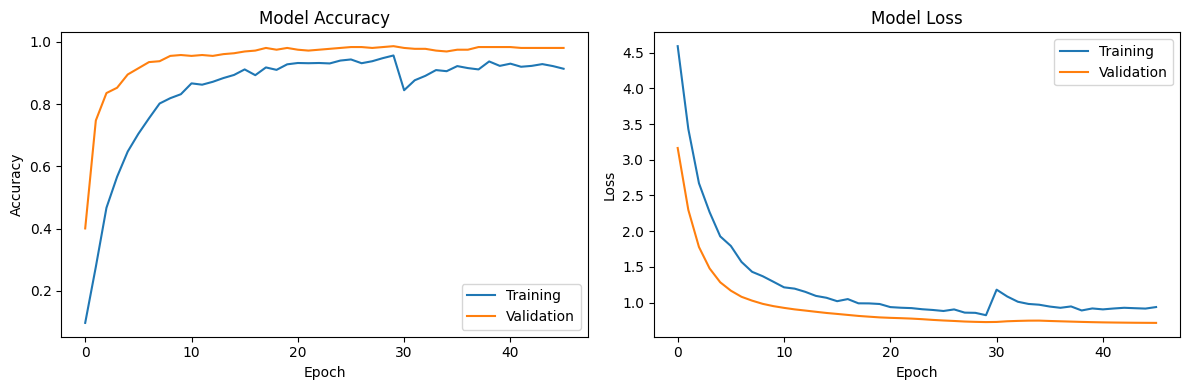

In [21]:
# Plot results
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'] + history_fine_enhanced.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'] + history_fine_enhanced.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'] + history_fine_enhanced.history['loss'], label='Training')
plt.plot(history.history['val_loss'] + history_fine_enhanced.history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()